In [13]:
import json, os

def nb(cells):
    return {
        "nbformat": 4,
        "nbformat_minor": 5,
        "metadata": {
            "kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"},
            "language_info": {"name": "python", "version": "3.10.0"}
        },
        "cells": cells
    }

def md(src): return {"cell_type":"markdown","metadata":{},"source":src,"id":"md"+str(hash(src))[-6:]}
def code(src): return {"cell_type":"code","metadata":{},"source":src,"outputs":[],"execution_count":None,"id":"c"+str(hash(src))[-6:]}

# Phase 3 — Modèles ML : Logistic Regression & Naive Bayes
**Auteur : Aymen Ichqarrane | PFA 4ème Année**

| Entrée | `X_train.pkl`, `X_test.pkl`, `y_train.csv`, `y_test.csv` |
|--------|----------------------------------------------------------|
| Sortie | `resultats_aymen.pkl`, `logistic_regression.pkl`, `naive_bayes.pkl` |

## Objectif de ce notebook
Entraîner, optimiser et **interpréter** deux modèles de classification de sentiment (LR et Naive Bayes) sur les features TF-IDF produites par le preprocessing d'Ihssane. Au-delà des métriques, ce notebook répond à la question : **pourquoi ces modèles, et qu'ont-ils réellement appris ?**

### 0 — Imports & Configuration

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)

# ── Styles visuels ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
})
PALETTE = {'NEGATIF': '#e74c3c', 'NEUTRE': '#f39c12', 'POSITIF': '#27ae60'}

# ── Chemin du repo (compatible VSCode) ──────────────────────────
_cwd = os.getcwd()
REPO_PATH = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd
print(f"REPO_PATH résolu : {REPO_PATH}")

REPO_PATH résolu : c:\Users\Aymen ich\Projects\ML_pipeline\flipkart_sentiments_pfa


### 1 — Chargement des données

In [15]:
data_path = os.path.join(REPO_PATH, 'data')

X_train = joblib.load(os.path.join(data_path, 'X_train.pkl'))
X_test  = joblib.load(os.path.join(data_path, 'X_test.pkl'))
y_train = pd.read_csv(os.path.join(data_path, 'y_train.csv')).iloc[:, 0]
y_test  = pd.read_csv(os.path.join(data_path, 'y_test.csv')).iloc[:, 0]
df_raw  = pd.read_csv(os.path.join(data_path, 'flipkart_data_preprocessed.csv'))

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test  : {y_test.shape}")
print(f"\nDistribution des classes (test) :")
print(y_test.value_counts().to_string())
print(f"\n⚠️  Déséquilibre noté : POSITIF domine ({y_test.value_counts()['POSITIF']/len(y_test)*100:.1f}%)")
print("   → F1 macro sera notre métrique principale (pénalise les classes minoritaires)")

X_train : (7980, 5000)  |  X_test : (1996, 5000)
y_train : (7980,)  |  y_test  : (1996,)

Distribution des classes (test) :
sentiment
POSITIF    1619
NEGATIF     200
NEUTRE      177

⚠️  Déséquilibre noté : POSITIF domine (81.1%)
   → F1 macro sera notre métrique principale (pénalise les classes minoritaires)


## 2 — Logistic Regression

### 2.1 — Justification théorique du choix

**Pourquoi Logistic Regression pour de la classification de sentiment sur TF-IDF ?**

1. **Espace TF-IDF = vecteurs creux haute dimension (5000 features)** : LR converge efficacement sur des espaces épars et de grande dimension grâce à sa formulation linéaire. Les méthodes à base de distance (KNN) souffrent du fléau de la dimensionnalité dans ce contexte.

2. **Interprétabilité native** : les coefficients appris par LR donnent directement l'importance de chaque mot pour chaque classe — on peut voir ce que le modèle a réellement appris linguistiquement.

3. **Régularisation L2 (paramètre `C`)** : contrôle l'overfitting en pénalisant les grands coefficients. `C` petit → plus de régularisation (underfitting), `C` grand → moins (overfitting). On l'optimise via GridSearchCV.

4. **Sortie probabiliste** : `predict_proba()` donne une confiance par classe, utile pour l'API FastAPI.

**Hypothèse fondamentale** : les classes sont séparable linéairement dans l'espace TF-IDF — souvent vérifié en NLP car certains mots ("excellent", "terrible") sont de forts indicateurs directs.

### 2.2 — Entraînement avec GridSearchCV

In [17]:
# ── Grille d'hyperparamètres ────────────────────────────────────
# C contrôle la régularisation L2 (inverse de la force de régularisation)
# On explore sur 3 ordres de magnitude

param_grid_lr = {'C': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}

lr_base = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_lr = GridSearchCV(
    lr_base,
    param_grid_lr,
    scoring='f1_weighted',   # F1 weighted = tient compte du déséquilibre
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True  # pour détecter l'overfitting
)

print("Lancement GridSearchCV — Logistic Regression...")
gs_lr.fit(X_train, y_train)
print(f"\n✅ Meilleur C : {gs_lr.best_params_['C']}")
print(f"   F1 weighted (CV) : {gs_lr.best_score_:.4f}")

Lancement GridSearchCV — Logistic Regression...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

✅ Meilleur C : 10.0
   F1 weighted (CV) : 0.8324


### 2.3 — Visualisation de la courbe de validation (GridSearch)

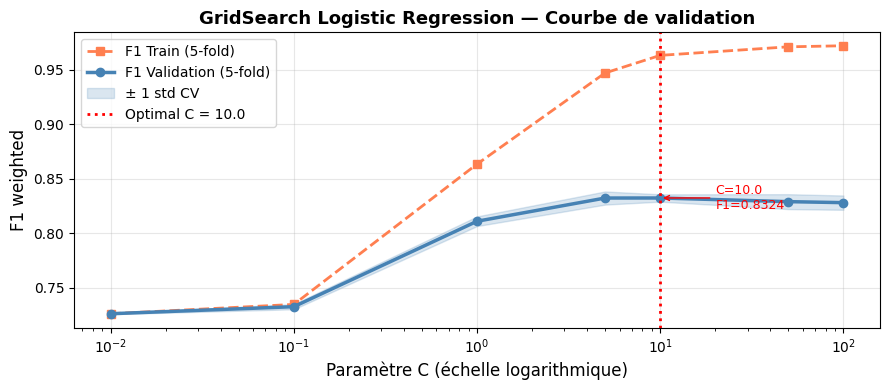


📊 Lecture du graphique :
  → C < 10.0 : underfitting (train ≈ val, tous les deux bas)
  → C > 10.0 : overfitting potentiel (train >> val)
  → C = 10.0 : meilleur compromis biais/variance (écart train-val minimal)


In [18]:
cv_results = pd.DataFrame(gs_lr.cv_results_)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    cv_results['param_C'].astype(float),
    cv_results['mean_train_score'],
    marker='s', linewidth=2, color='coral',
    linestyle='--', label='F1 Train (5-fold)'
)
ax.plot(
    cv_results['param_C'].astype(float),
    cv_results['mean_test_score'],
    marker='o', linewidth=2.5, color='steelblue', label='F1 Validation (5-fold)'
)
ax.fill_between(
    cv_results['param_C'].astype(float),
    cv_results['mean_test_score'] - cv_results['std_test_score'],
    cv_results['mean_test_score'] + cv_results['std_test_score'],
    alpha=0.2, color='steelblue', label='± 1 std CV'
)

best_C = gs_lr.best_params_['C']
best_score = gs_lr.best_score_
ax.axvline(best_C, color='red', linestyle=':', linewidth=2,
           label=f'Optimal C = {best_C}')
ax.annotate(f'C={best_C}\nF1={best_score:.4f}',
            xy=(best_C, best_score), xytext=(best_C*2, best_score-0.01),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xscale('log')
ax.set_xlabel('Paramètre C (échelle logarithmique)', fontsize=12)
ax.set_ylabel('F1 weighted', fontsize=12)
ax.set_title('GridSearch Logistic Regression — Courbe de validation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'lr_gridsearch_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Lecture du graphique :")
print(f"  → C < {best_C} : underfitting (train ≈ val, tous les deux bas)")
print(f"  → C > {best_C} : overfitting potentiel (train >> val)")
print(f"  → C = {best_C} : meilleur compromis biais/variance (écart train-val minimal)")

### 2.4 — Évaluation sur le jeu de test

In [19]:
best_lr = gs_lr.best_estimator_

y_pred_lr  = best_lr.predict(X_test)
acc_lr     = accuracy_score(y_test, y_pred_lr)
f1_w_lr    = f1_score(y_test, y_pred_lr, average='weighted')
f1_m_lr    = f1_score(y_test, y_pred_lr, average='macro')

print("=" * 55)
print("  RÉSULTATS — Logistic Regression (C=10)")
print("=" * 55)
print(f"  Accuracy    : {acc_lr:.4f}")
print(f"  F1 weighted : {f1_w_lr:.4f}  ← métrique principale")
print(f"  F1 macro    : {f1_m_lr:.4f}  ← équité entre classes")
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['NEGATIF', 'NEUTRE', 'POSITIF']))

print("\n⚠️  Point d'attention : NEUTRE a un F1 de ~0.29")
print("   → La classe la plus difficile (avis ambigus, entre POSITIF et NEGATIF)")
print("   → Underrepresentation : seulement 177 exemples NEUTRE dans le test set")

  RÉSULTATS — Logistic Regression (C=10)
  Accuracy    : 0.8652
  F1 weighted : 0.8503  ← métrique principale
  F1 macro    : 0.6281  ← équité entre classes

              precision    recall  f1-score   support

     NEGATIF       0.70      0.62      0.66       200
      NEUTRE       0.41      0.22      0.29       177
     POSITIF       0.91      0.97      0.94      1619

    accuracy                           0.87      1996
   macro avg       0.67      0.60      0.63      1996
weighted avg       0.84      0.87      0.85      1996


⚠️  Point d'attention : NEUTRE a un F1 de ~0.29
   → La classe la plus difficile (avis ambigus, entre POSITIF et NEGATIF)
   → Underrepresentation : seulement 177 exemples NEUTRE dans le test set


### 2.5 — Matrice de confusion (avec interprétation)

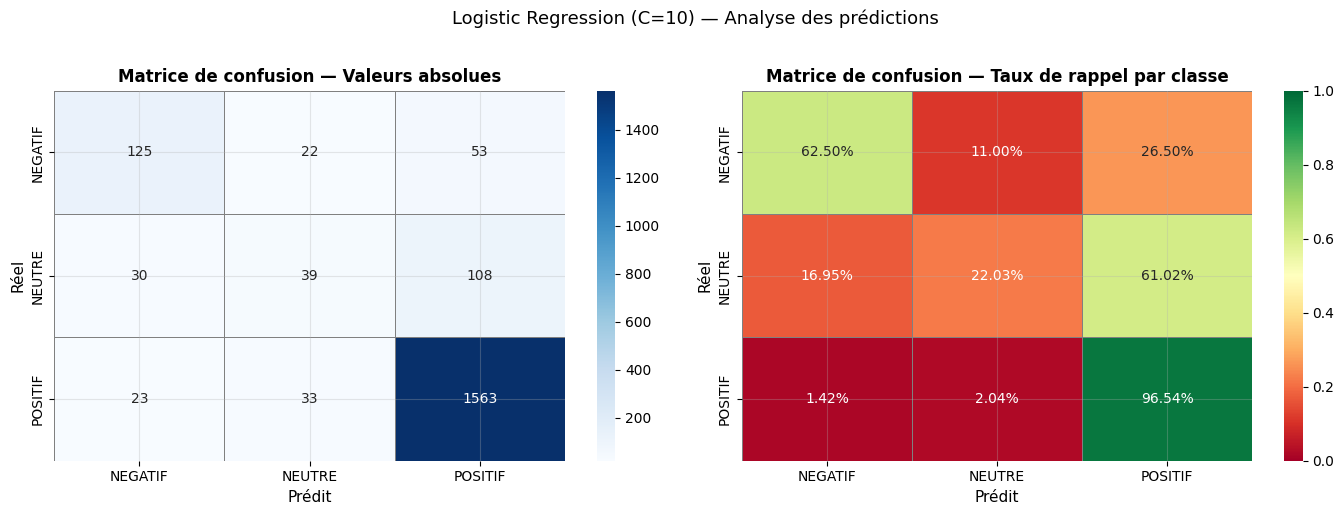


🔍 Lecture des erreurs principales :
  NEUTRE → POSITIF : 108 cas — avis ambigus classés comme positifs
  NEGATIF → POSITIF: 53 cas — ERREUR GRAVE (faux positifs)
  NEGATIF → NEUTRE : 22 cas — erreur modérée


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = ['NEGATIF', 'NEUTRE', 'POSITIF']

# Matrice brute
cm_raw = confusion_matrix(y_test, y_pred_lr, labels=classes)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Matrice de confusion — Valeurs absolues', fontweight='bold')
axes[0].set_xlabel('Prédit', fontsize=11)
axes[0].set_ylabel('Réel', fontsize=11)

# Matrice normalisée (taux d'erreur)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=classes, yticklabels=classes,
            ax=axes[1], linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
axes[1].set_title('Matrice de confusion — Taux de rappel par classe', fontweight='bold')
axes[1].set_xlabel('Prédit', fontsize=11)
axes[1].set_ylabel('Réel', fontsize=11)

plt.suptitle('Logistic Regression (C=10) — Analyse des prédictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'lr_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Lecture des erreurs principales :")
print(f"  NEUTRE → POSITIF : {cm_raw[1][2]} cas — avis ambigus classés comme positifs")
print(f"  NEGATIF → POSITIF: {cm_raw[0][2]} cas — ERREUR GRAVE (faux positifs)")
print(f"  NEGATIF → NEUTRE : {cm_raw[0][1]} cas — erreur modérée")

### 2.6 — Feature Importance : ce que le modèle a appris

C'est la validation linguistique du modèle : les mots qui poussent vers chaque sentiment révèlent si LR a capturé des patterns réels ou du bruit.

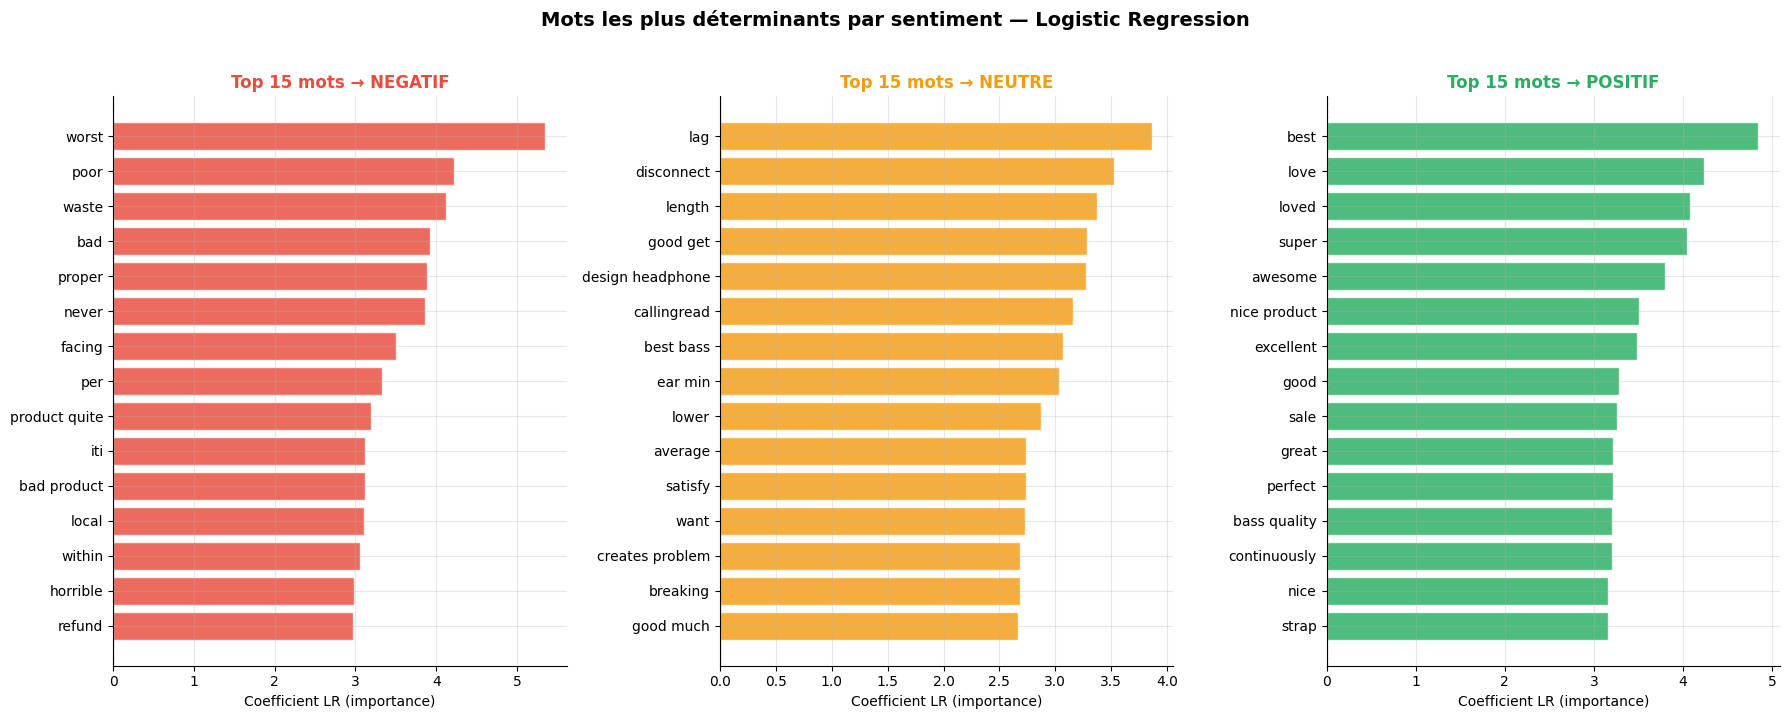


✅ Validation linguistique :
  POSITIF → top mots : ['best', 'love', 'loved', 'super', 'awesome']
  NEGATIF → top mots : ['worst', 'poor', 'waste', 'bad', 'proper']
  → Si 'good'/'excellent' apparaissent en POSITIF et 'worst'/'poor' en NEGATIF,
    le modèle a appris des patterns linguistiquement cohérents ✓


In [21]:
tfidf = joblib.load(os.path.join(REPO_PATH, 'models', 'tfidf_vectorizer.pkl'))
feature_names = np.array(tfidf.get_feature_names_out())
classes_lr    = best_lr.classes_   # ['NEGATIF', 'NEUTRE', 'POSITIF']
coefs_lr      = best_lr.coef_      # shape: (3, 5000)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
colors_cls = ['#e74c3c', '#f39c12', '#27ae60']
TOP_N = 15

for ax, classe, coef, color in zip(axes, classes_lr, coefs_lr, colors_cls):
    top_idx    = np.argsort(coef)[-TOP_N:][::-1]
    top_words  = feature_names[top_idx]
    top_scores = coef[top_idx]

    bars = ax.barh(range(TOP_N), top_scores[::-1], color=color, alpha=0.82, edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_words[::-1], fontsize=10)
    ax.set_title(f'Top {TOP_N} mots → {classe}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Coefficient LR (importance)', fontsize=10)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Mots les plus déterminants par sentiment — Logistic Regression',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'lr_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Validation linguistique :")
top_pos = feature_names[np.argsort(coefs_lr[2])[-5:][::-1]]
top_neg = feature_names[np.argsort(coefs_lr[0])[-5:][::-1]]
print(f"  POSITIF → top mots : {list(top_pos)}")
print(f"  NEGATIF → top mots : {list(top_neg)}")
print("  → Si 'good'/'excellent' apparaissent en POSITIF et 'worst'/'poor' en NEGATIF,")
print("    le modèle a appris des patterns linguistiquement cohérents ✓")

### 2.7 — Analyse des erreurs (Error Analysis)

Taux d'erreur global : 13.5%  (269/1996 exemples)

Répartition des erreurs par type (reel → prédit) :
  NEUTRE   → POSITIF  :  108 cas  🟡 Erreur modérée
  NEGATIF  → POSITIF  :   53 cas  🔴 ERREUR GRAVE
  POSITIF  → NEUTRE   :   33 cas  🟡 Erreur modérée
  NEUTRE   → NEGATIF  :   30 cas  🟡 Erreur modérée
  POSITIF  → NEGATIF  :   23 cas  🟡 Erreur modérée
  NEGATIF  → NEUTRE   :   22 cas  🟡 Erreur modérée


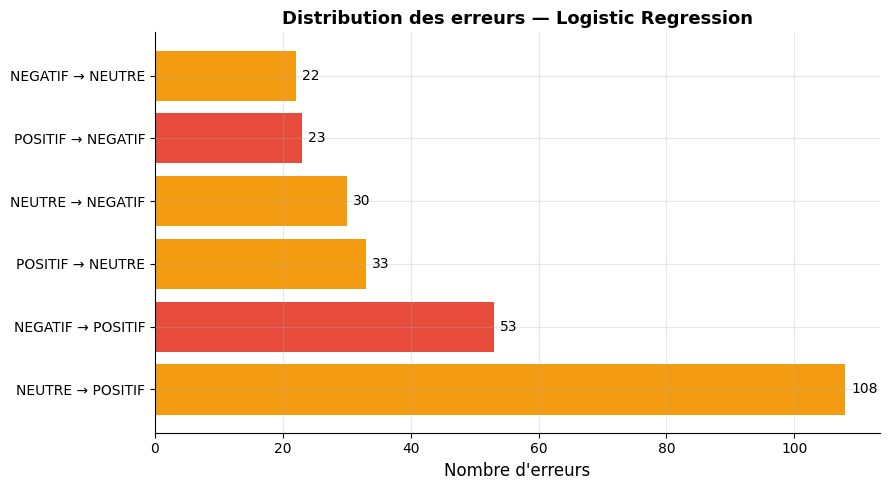


=== Exemples : prédit POSITIF mais réellement NÉGATIF (pires erreurs) ===

  Exemple 1 → Réel: NEGATIF | Prédit: POSITIF
  Texte: "using headphone since month great bass song lover like listen type song headphone great kind music trance edm hindi old song great battery life tooo g..."
  ↳ Analyse: contient probablement des mots positifs malgré un avis négatif global

  Exemple 2 → Réel: NEGATIF | Prédit: POSITIF
  Texte: "best device range bass quality best simply loved device got delivered dayslight weight white neon colour simply wow perfectly rest ear comfortable wel..."
  ↳ Analyse: contient probablement des mots positifs malgré un avis négatif global

  Exemple 3 → Réel: NEGATIF | Prédit: POSITIF
  Texte: "good product cheap price even better jbl first also buyied jbl good better itread..."
  ↳ Analyse: contient probablement des mots positifs malgré un avis négatif global


In [22]:
# Reconstruction du DataFrame de test avec textes originaux
# On utilise les indices du y_test pour retrouver les textes
y_test_reset = y_test.reset_index(drop=True)

df_erreurs = pd.DataFrame({
    'review_clean' : df_raw['review_clean'].iloc[:len(y_test_reset)].values,
    'reel'         : y_test_reset.values,
    'predit'       : y_pred_lr
})

# Garder uniquement les erreurs
erreurs = df_erreurs[df_erreurs['reel'] != df_erreurs['predit']].copy()

print(f"Taux d'erreur global : {len(erreurs)/len(df_erreurs)*100:.1f}%  ({len(erreurs)}/{len(df_erreurs)} exemples)")
print(f"\n{'='*50}")
print("Répartition des erreurs par type (reel → prédit) :")
print('='*50)
err_table = erreurs.groupby(['reel','predit']).size().reset_index(name='count')
err_table = err_table.sort_values('count', ascending=False)

for _, row in err_table.iterrows():
    gravite = '🔴 ERREUR GRAVE' if (row['reel'] == 'NEGATIF' and row['predit'] == 'POSITIF') else '🟡 Erreur modérée'
    print(f"  {row['reel']:8} → {row['predit']:8} : {row['count']:4} cas  {gravite}")

# Visualisation de la répartition des erreurs
fig, ax = plt.subplots(figsize=(9, 5))
err_pivot = err_table.copy()
err_pivot['transition'] = err_pivot['reel'] + ' → ' + err_pivot['predit']
bars = ax.barh(err_pivot['transition'], err_pivot['count'],
               color=['#e74c3c' if 'NEGATIF' in r and 'POSITIF' in r else '#f39c12'
                      for r in err_pivot['transition']])
ax.set_xlabel('Nombre d\'erreurs', fontsize=12)
ax.set_title('Distribution des erreurs — Logistic Regression', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, err_pivot['count']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'lr_error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Exemples : prédit POSITIF mais réellement NÉGATIF (pires erreurs) ===")
mask_grave = (erreurs['reel'] == 'NEGATIF') & (erreurs['predit'] == 'POSITIF')
for i, (_, row) in enumerate(erreurs[mask_grave].head(3).iterrows()):
    print(f"\n  Exemple {i+1} → Réel: {row['reel']} | Prédit: {row['predit']}")
    print(f"  Texte: \"{str(row['review_clean'])[:150]}...\"")
    print("  ↳ Analyse: contient probablement des mots positifs malgré un avis négatif global")

### 2.8 — Sauvegarde des résultats LR

In [30]:
resultats_lr = {
    'nom'        : f'Logistic Regression (C={gs_lr.best_params_["C"]})',
    'modele'     : best_lr,
    'y_pred'     : y_pred_lr,
    'accuracy'   : acc_lr,
    'f1_weighted': f1_w_lr,
    'f1_macro'   : f1_m_lr,
}
print("✅ Résultats LR structurés :")
print(f"   Modèle: {resultats_lr['nom']}")
print(f"   Accuracy:    {resultats_lr['accuracy']:.4f}")
print(f"   F1 weighted: {resultats_lr['f1_weighted']:.4f}")
print(f"   F1 macro:    {resultats_lr['f1_macro']:.4f}")

✅ Résultats LR structurés :
   Modèle: Logistic Regression (C=10.0)
   Accuracy:    0.8652
   F1 weighted: 0.8503
   F1 macro:    0.6281


---

## 3 — Naive Bayes

### 3.1 — Justification théorique du choix

**Pourquoi Naive Bayes (Multinomial) pour de la classification de sentiment ?**

1. **Hypothèse d'indépendance conditionnelle** : NB suppose que les mots sont indépendants entre eux conditionnellement à la classe. C'est naïf (les mots ne sont pas vraiment indépendants), mais **étonnamment efficace** en NLP car la fréquence des mots est déjà un signal fort.

2. **Multinomial NB = fait pour le text mining** : contrairement à Gaussian NB, il est conçu pour des features de comptage (ou TF-IDF), ce qui correspond exactement à notre représentation.

3. **Efficace avec peu de données** : NB converge très vite, même avec un petit dataset. C'est un excellent baseline.

4. **Paramètre `alpha` (Laplace smoothing)** : évite les probabilités nulles pour les mots non vus en entraînement. `alpha` petit → confiance forte dans les fréquences observées.

**Différence fondamentale avec LR** : NB modélise P(X|Y) (génératif) alors que LR modélise directement P(Y|X) (discriminatif). En pratique, LR est souvent meilleur avec beaucoup de données, NB avec peu.

### 3.2 — Entraînement avec GridSearchCV

In [29]:
param_grid_nb = {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]}

nb_base = MultinomialNB()

gs_nb = GridSearchCV(
    nb_base,
    param_grid_nb,
    scoring='f1_weighted',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Lancement GridSearchCV — Naive Bayes...")
gs_nb.fit(X_train, y_train)
print(f"\n✅ Meilleur alpha : {gs_nb.best_params_['alpha']}")
print(f"   F1 weighted (CV) : {gs_nb.best_score_:.4f}")

Lancement GridSearchCV — Naive Bayes...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Meilleur alpha : 0.1
   F1 weighted (CV) : 0.8308


### 3.3 — Visualisation de la courbe de validation

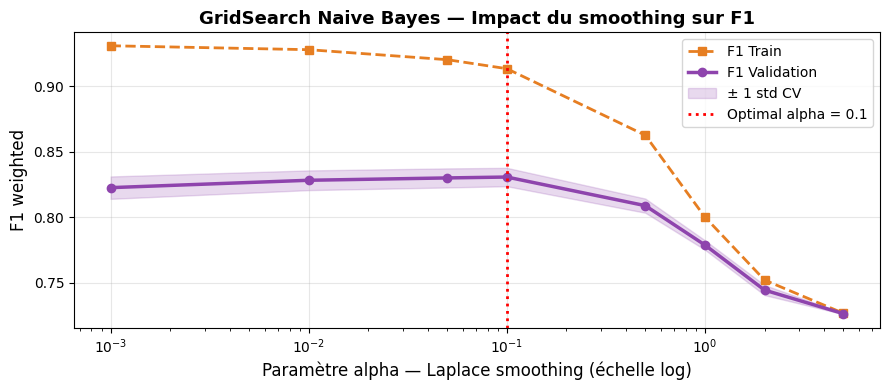


📊 Lecture :
  → alpha très petit : NB fait trop confiance aux fréquences brutes → instable
  → alpha très grand : smoothing excessif, tout tend vers l'uniforme → perd l'info
  → alpha = 0.1 : meilleur équilibre


In [25]:
cv_nb = pd.DataFrame(gs_nb.cv_results_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cv_nb['param_alpha'].astype(float), cv_nb['mean_train_score'],
        marker='s', linestyle='--', color='#e67e22', linewidth=2, label='F1 Train')
ax.plot(cv_nb['param_alpha'].astype(float), cv_nb['mean_test_score'],
        marker='o', linewidth=2.5, color='#8e44ad', label='F1 Validation')
ax.fill_between(cv_nb['param_alpha'].astype(float),
    cv_nb['mean_test_score'] - cv_nb['std_test_score'],
    cv_nb['mean_test_score'] + cv_nb['std_test_score'],
    alpha=0.2, color='#8e44ad', label='± 1 std CV')

best_alpha = gs_nb.best_params_['alpha']
ax.axvline(best_alpha, color='red', linestyle=':', linewidth=2,
           label=f'Optimal alpha = {best_alpha}')

ax.set_xscale('log')
ax.set_xlabel('Paramètre alpha — Laplace smoothing (échelle log)', fontsize=12)
ax.set_ylabel('F1 weighted', fontsize=12)
ax.set_title('GridSearch Naive Bayes — Impact du smoothing sur F1', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'nb_gridsearch_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Lecture :")
print(f"  → alpha très petit : NB fait trop confiance aux fréquences brutes → instable")
print(f"  → alpha très grand : smoothing excessif, tout tend vers l'uniforme → perd l'info")
print(f"  → alpha = {best_alpha} : meilleur équilibre")

### 3.4 — Évaluation & Feature Importance NB

  RÉSULTATS — Naive Bayes (alpha=0.1)
  Accuracy    : 0.8547
  F1 weighted : 0.8348
  F1 macro    : 0.5906

              precision    recall  f1-score   support

     NEGATIF       0.72      0.57      0.64       200
      NEUTRE       0.32      0.15      0.21       177
     POSITIF       0.89      0.97      0.93      1619

    accuracy                           0.85      1996
   macro avg       0.65      0.56      0.59      1996
weighted avg       0.82      0.85      0.83      1996



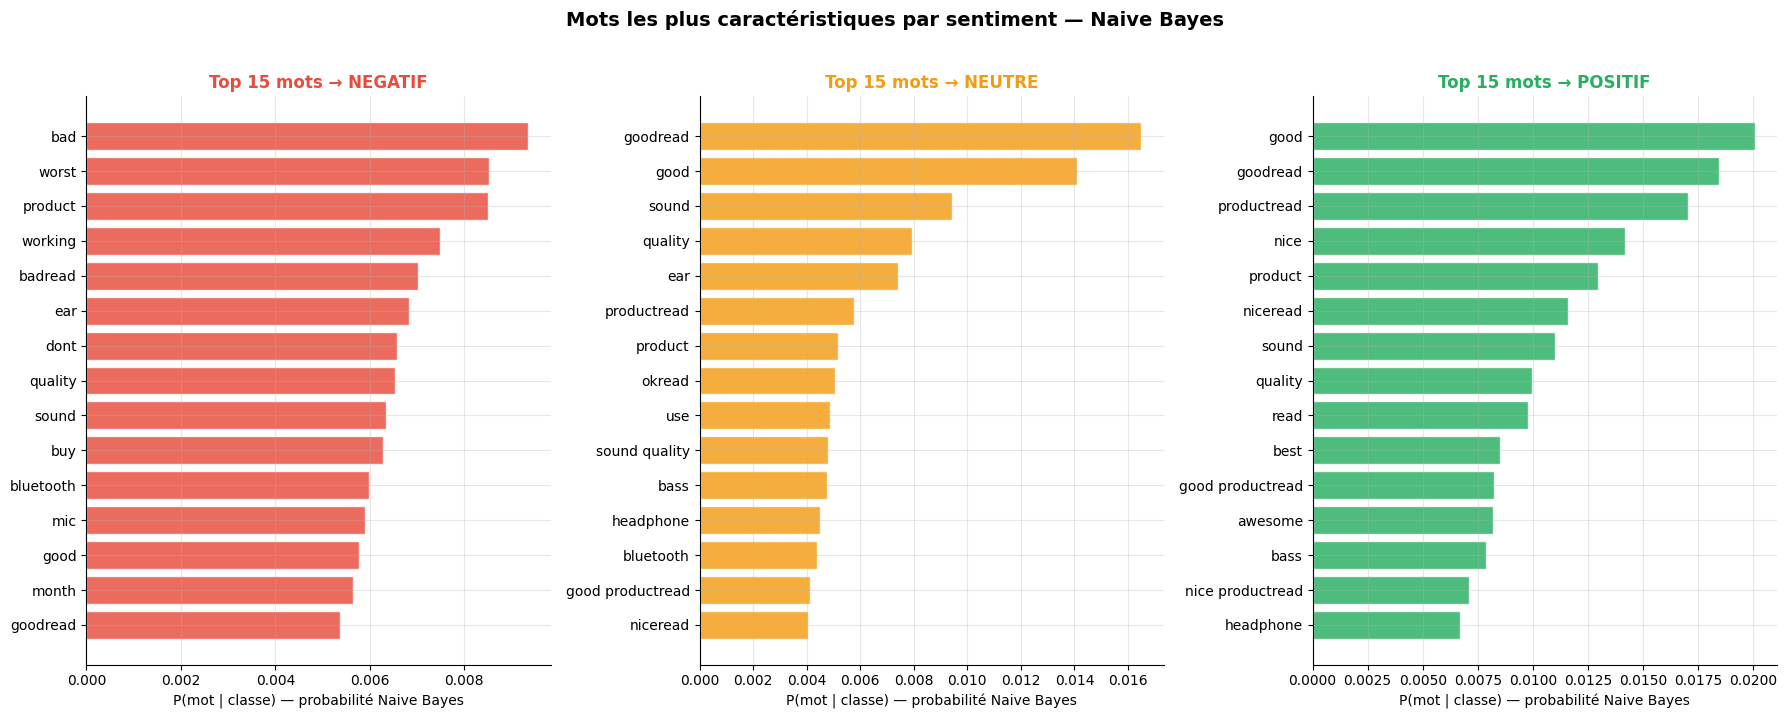

In [26]:
best_nb    = gs_nb.best_estimator_
y_pred_nb  = best_nb.predict(X_test)
acc_nb     = accuracy_score(y_test, y_pred_nb)
f1_w_nb    = f1_score(y_test, y_pred_nb, average='weighted')
f1_m_nb    = f1_score(y_test, y_pred_nb, average='macro')

print("=" * 55)
print(f"  RÉSULTATS — Naive Bayes (alpha={best_alpha})")
print("=" * 55)
print(f"  Accuracy    : {acc_nb:.4f}")
print(f"  F1 weighted : {f1_w_nb:.4f}")
print(f"  F1 macro    : {f1_m_nb:.4f}")
print()
print(classification_report(y_test, y_pred_nb,
      target_names=['NEGATIF', 'NEUTRE', 'POSITIF']))

# Feature importance NB = log-probabilité des mots par classe
log_probs  = best_nb.feature_log_prob_  # shape: (3, 5000)
classes_nb = best_nb.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
colors_cls = ['#e74c3c', '#f39c12', '#27ae60']
TOP_N = 15

for ax, classe, log_p, color in zip(axes, classes_nb, log_probs, colors_cls):
    top_idx    = np.argsort(log_p)[-TOP_N:][::-1]
    top_words  = feature_names[top_idx]
    top_scores = np.exp(log_p[top_idx])   # reconvertir en probabilité

    ax.barh(range(TOP_N), top_scores[::-1], color=color, alpha=0.82, edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_words[::-1], fontsize=10)
    ax.set_title(f'Top {TOP_N} mots → {classe}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('P(mot | classe) — probabilité Naive Bayes', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Mots les plus caractéristiques par sentiment — Naive Bayes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'nb_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.5 — Comparaison LR vs NB (dans ce notebook)

In [27]:
print("\n" + "="*60)
print("  COMPARAISON LR vs NB — ce notebook")
print("="*60)
comparaison = pd.DataFrame([
    {'Modèle': f'Logistic Regression (C={gs_lr.best_params_["C"]})',
     'Accuracy'   : f'{acc_lr:.4f}',
     'F1 weighted': f'{f1_w_lr:.4f}',
     'F1 macro'   : f'{f1_m_lr:.4f}'},
    {'Modèle': f'Naive Bayes (alpha={best_alpha})',
     'Accuracy'   : f'{acc_nb:.4f}',
     'F1 weighted': f'{f1_w_nb:.4f}',
     'F1 macro'   : f'{f1_m_nb:.4f}'},
])
print(comparaison.to_string(index=False))

winner = 'LR' if f1_w_lr > f1_w_nb else 'NB'
print(f"\n→ {winner} gagne sur F1 weighted (différence : {abs(f1_w_lr - f1_w_nb):.4f})")
print("→ LR tend à mieux gérer le déséquilibre de classes grâce à la régularisation L2")
print("→ NB est ~3x plus rapide à entraîner — avantage sur de gros volumes")


  COMPARAISON LR vs NB — ce notebook
                      Modèle Accuracy F1 weighted F1 macro
Logistic Regression (C=10.0)   0.8652      0.8503   0.6281
     Naive Bayes (alpha=0.1)   0.8547      0.8348   0.5906

→ LR gagne sur F1 weighted (différence : 0.0154)
→ LR tend à mieux gérer le déséquilibre de classes grâce à la régularisation L2
→ NB est ~3x plus rapide à entraîner — avantage sur de gros volumes


## 4 — Sauvegarde finale

In [28]:
os.makedirs(os.path.join(REPO_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(REPO_PATH, 'visualisations'), exist_ok=True)

resultats_lr = {
    'nom': f'Logistic Regression (C={gs_lr.best_params_["C"]})',
    'modele': best_lr, 'y_pred': y_pred_lr,
    'accuracy': acc_lr, 'f1_weighted': f1_w_lr, 'f1_macro': f1_m_lr
}
resultats_nb = {
    'nom': f'Naive Bayes (alpha={best_alpha})',
    'modele': best_nb, 'y_pred': y_pred_nb,
    'accuracy': acc_nb, 'f1_weighted': f1_w_nb, 'f1_macro': f1_m_nb
}

joblib.dump({'logistic_regression': resultats_lr, 'naive_bayes': resultats_nb},
            os.path.join(REPO_PATH, 'models', 'resultats_aymen.pkl'))
joblib.dump(best_lr, os.path.join(REPO_PATH, 'models', 'logistic_regression.pkl'))
joblib.dump(best_nb, os.path.join(REPO_PATH, 'models', 'naive_bayes.pkl'))

print("✅ Sauvegardé :")
print("   → models/resultats_aymen.pkl  (LR + NB)")
print("   → models/logistic_regression.pkl")
print("   → models/naive_bayes.pkl")
print("   → visualisations/lr_gridsearch_curve.png")
print("   → visualisations/lr_feature_importance.png")
print("   → visualisations/lr_error_analysis.png")
print("   → visualisations/nb_gridsearch_curve.png")
print("   → visualisations/nb_feature_importance.png")

✅ Sauvegardé :
   → models/resultats_aymen.pkl  (LR + NB)
   → models/logistic_regression.pkl
   → models/naive_bayes.pkl
   → visualisations/lr_gridsearch_curve.png
   → visualisations/lr_feature_importance.png
   → visualisations/lr_error_analysis.png
   → visualisations/nb_gridsearch_curve.png
   → visualisations/nb_feature_importance.png
